# CNN Architecture 이해 및 최적화 실습 - 홍은비

**실습 시간: 120분 (2시간)** · **구성: 2인 1조(박영신, 홍은비)**

---

## 실습 목표
1. 기본 CNN(Vanilla Skeleton)의 구조와 학습 과정을 이해한다.
2. 레이어 구성, Optimizer, Activation Function을 직접 바꿔보며 **왜 그렇게 바꿨는지** 논리를 세운다.
3. Train/Test 성능 그래프를 통해 **학습 안정성**과 **Overfitting 완화 여부**를 확인한다.

## 오늘 지켜야 할 약속
- 이것저것 바꿔봤더니 이게 제일 좋았어요 로 끝내지 않기
- **바꾸기 전에 왜 이렇게 바꾸면 좋아질 것 같다는 가설을 먼저 적기**
- 바꾼 후 결과가 가설과 맞았는지, 틀렸다면 왜 그런지 생각해보기

> 이 노트북은 코드를 몰라도 따라올 수 있도록, 실행만 하면 되는 셀과 **직접 수정해야 하는 셀(✏️ 표시)** 을 구분해두었습니다.
코드 전체 구조를 외울 필요는 없습니다. 어떤 것을 바꾸면 어떤 효과가 있는지 메뉴판을 보고 골라 담는다고 생각하세요.

---


## 진행 순서 (총 120분)

| 단계 | 내용 | 시간 |
|---|---|---|
| 0 | 환경설정 & 데이터 로드 | 10분 |
| 1 | 데이터 살펴보기 (EDA) | 10분 |
| 2 | Vanilla CNN(기본 모델) 학습 → 베이스라인 확인 | 20분 |
| 3 | 미션 1: 아키텍처 개선 설계서 작성 (가설 세우기) | 10분 |
| 4 | 미션 2: 아키텍처 개선 & 재학습 (최소 2회 실험) | 45분 |
| 5 | 결과 비교 & 정리 | 15분 |
| 6 | 보고서 작성 및 제출 | 10분 |

시간이 부족하면 미션 4의 실험 횟수를 줄이더라도, **1개의 실험만은 가설→결과→해석까지 끝까지 완성**하는 것을 우선하세요.


---
## 0. 환경설정 & 데이터 로드 (10분)

이 실습은 **Fashion-MNIST** 데이터셋을 사용합니다.
- 28×28 흑백 이미지, 10개 카테고리(티셔츠, 바지, 가방, 신발 등)
- 오픈 데이터셋이며 특정 도메인 지식이 필요 없어 실습에 적합합니다.
- 아래 셀은 **그대로 실행만** 하면 됩니다.


In [3]:
# 필요한 라이브러리 불러오기 (Colab에는 기본 설치되어 있습니다)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow 버전:", tf.__version__)


TensorFlow 버전: 2.21.0


In [4]:
# 데이터 불러오기
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 32명이 동시에 실습하는 환경 + CPU 환경을 고려해
# 학습 속도를 위해 데이터 일부만 사용합니다 (성능 자체보다 구조 이해가 목적입니다)
N_TRAIN = 6000   # 전체 60,000장 중 6,000장만 사용
N_TEST = 1500    # 전체 10,000장 중 1,500장만 사용

idx_train = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train, y_train = x_train_full[idx_train], y_train_full[idx_train]
x_test, y_test = x_test_full[idx_test], y_test_full[idx_test]

# 정규화 (0~255 -> 0~1) + CNN 입력 형태로 채널 차원 추가 (28,28) -> (28,28,1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 8us/step 
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (6000, 28, 28, 1) Test shape: (1500, 28, 28, 1)


---
## 1. 데이터 살펴보기 (10분)

본격적인 모델링 전에, 우리가 다룰 데이터가 어떤 모습인지 눈으로 확인합니다.


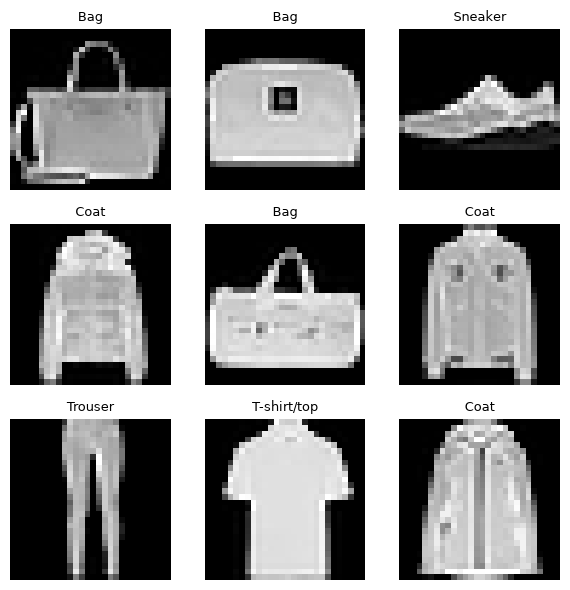

In [5]:
# 샘플 이미지 9장 확인
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


/var/folders/kn/jw0mbt3j4t75946kwg138dqh0000gn/T/ipykernel_93747/489260880.py:7: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kn/jw0mbt3j4t75946kwg138dqh0000gn/T/ipykernel_93747/489260880.py:7: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kn/jw0mbt3j4t75946kwg138dqh0000gn/T/ipykernel_93747/489260880.py:7: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kn/jw0mbt3j4t75946kwg138dqh0000gn/T/ipykernel_93747/489260880.py:7: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kn/jw0mbt3j4t75946kwg138dqh0000gn/T/ipykernel_93747/489260880.py:7: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kn/jw0mbt3j4t75946kwg138dqh0000gn/T/ipykernel_937

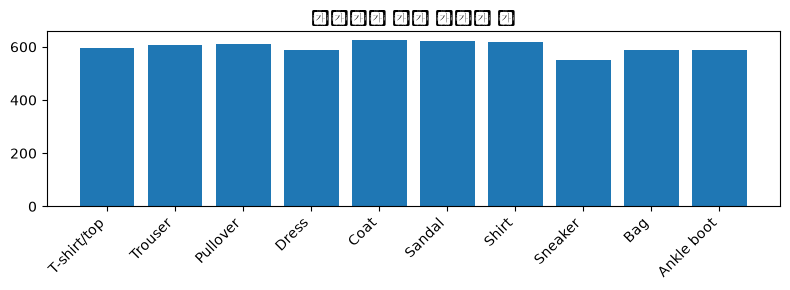

In [6]:
# 클래스별 데이터 개수 확인 (한쪽으로 쏠려있지 않은지 확인하는 습관)
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 3))
plt.bar([class_names[u] for u in unique], counts)
plt.xticks(rotation=45, ha="right")
plt.title("클래스별 학습 데이터 수")
plt.tight_layout()
plt.show()


**생각해보기 (답을 적을 필요는 없습니다. 팀원과 짧게 이야기 나눠보세요)**
- 이미지 크기가 28×28×1 이라는 것은 무엇을 의미할까요? (힌트: Part B, Tensor Shape)
  - 28*28 크기의 이미지에서 픽셀이 1개?인 3차원 배열 (3D Tensor/ 높이, 너비, 채널 수)
- 데이터가 10개 클래스에 고르게 분포되어 있나요? 
  - 47000~55000 사이에 분포



---
## 2. Vanilla CNN (기본 모델) 학습 (20분)

먼저 **아주 단순한 CNN**을 만들어 학습시켜 보겠습니다. 이 모델을 오늘의 **베이스라인(기준점)** 으로 삼습니다.

### Vanilla Skeleton 구조
```
입력(28,28,1)
 → Conv2D (필터 8개, 3x3, activation='sigmoid')
 → Flatten
 → Dense (10, activation='softmax')
```

일부러 **성능이 잘 안 나오도록** 아주 단순하게 설계했습니다.
- Conv 레이어가 1개뿐이라 특징을 충분히 뽑지 못합니다.
- Activation이 `sigmoid`라 Part B에서 배운 Gradient Vanishing이 발생하기 쉽습니다.
- Pooling, BatchNorm, Dropout 등 어떤 보조 장치도 없습니다.
- Optimizer도 가장 단순한 `SGD`(고정 학습률)를 사용합니다.

여러분의 미션은 이 구조를 **여러분의 논리로 개선**하는 것입니다.


-->기존 sigmoid는 입력값이 너무 크거나 작은 포화 영역에서 기울기가 0에 가까워져서 학습이 느려질 수 있다. 따라서 양수 영역에서 기울기가 일정한 ReLU activation으로 변경하겠다. 그러면 gradient 전달과 학습 속도가 개선될 것으로 예상한다.


In [ ]:
def build_vanilla_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        # layers.Conv2D(8, (3, 3), activation="sigmoid"),
        layers.Conv2D(8, (3, 3), activation="relu"), 
        layers.Flatten(),
        layers.Dense(10, activation="softmax"),
    ], name="vanilla_cnn")
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

vanilla_model = build_vanilla_model()
vanilla_model.summary()


Model: "vanilla_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,170 (211.60 KB)

 Trainable params: 54,170 (211.60 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 학습을 도와주는 헬퍼 함수 (그대로 실행하세요 - 앞으로 계속 재사용합니다)
history_store = {}  # 실험 결과를 모아두는 저장소

def train_and_record(model, name, epochs=15, batch_size=64):
    print(f"\n=== [{name}] 학습 시작 ===")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    history_store[name] = history.history
    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]
    gap = train_acc - val_acc
    print(f"[{name}] 최종 Train Acc: {train_acc:.3f} | Test Acc: {val_acc:.3f} | 격차(Overfitting 정도): {gap:.3f}")
    return history

def plot_history(names=None):
    # 저장된 실험들의 Loss/Accuracy 곡선을 한 화면에 비교
    names = names or list(history_store.keys())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name in names:
        h = history_store[name]
        axes[0].plot(h["loss"], label=f"{name} (train)")
        axes[0].plot(h["val_loss"], linestyle="--", label=f"{name} (test)")
        axes[1].plot(h["accuracy"], label=f"{name} (train)")
        axes[1].plot(h["val_accuracy"], linestyle="--", label=f"{name} (test)")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def summary_table():
    # 실험별 최종 성능을 표로 요약
    print(f"{'실험명':<20}{'Train Acc':>12}{'Test Acc':>12}{'격차':>10}")
    for name, h in history_store.items():
        tr, va = h["accuracy"][-1], h["val_accuracy"][-1]
        print(f"{name:<20}{tr:>12.3f}{va:>12.3f}{tr-va:>10.3f}")



=== [1_Vanilla_Baseline] 학습 시작 ===
[1_Vanilla_Baseline] 최종 Train Acc: 0.754 | Test Acc: 0.760 | 격차(Overfitting 정도): -0.006


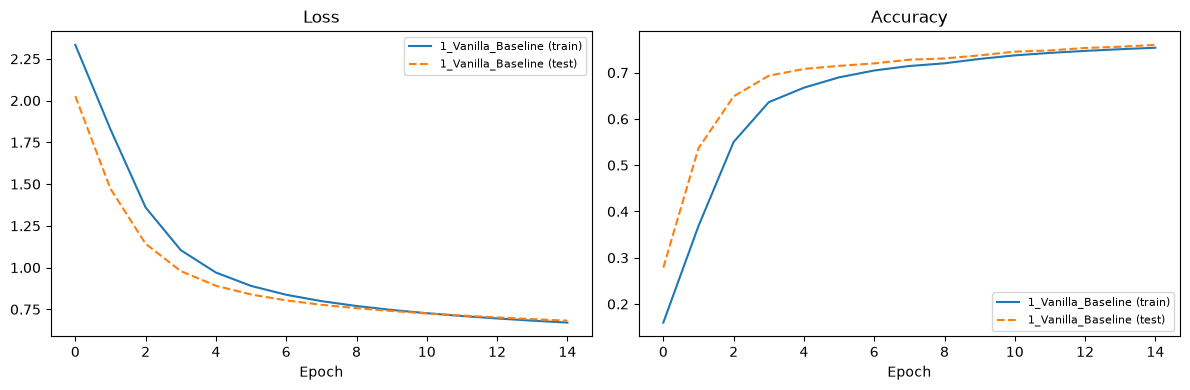

In [9]:
# 베이스라인 학습 (약 1~2분 소요)
train_and_record(vanilla_model, "1_Vanilla_Baseline", epochs=15)
plot_history(["1_Vanilla_Baseline"])


**베이스라인 결과를 보고 확인할 것**
- Train Accuracy와 Test Accuracy의 격차가 큰가요, 작은가요?
- Loss 그래프가 잘 떨어지고 있나요, 아니면 정체되어 있나요? (`sigmoid` + 얕은 구조의 한계일 수 있습니다)

이 두 가지 관찰이 바로 **다음 단계에서 "무엇을 왜 바꿀지"의 출발점**입니다.


---
## 3. 미션 1: 아키텍처 개선 설계서 작성 (10분)

바로 코드를 고치지 말고, 먼저 아래 표를 **팀원과 상의해서 채워보세요.**
(이 표의 내용은 이후 제출할 보고서에 그대로 활용됩니다.)

| 항목 | 여러분의 계획 |
|---|---|
| 베이스라인에서 가장 문제라고 생각하는 부분은? | (예: 레이어가 1개뿐이라 특징 추출이 부족하다 / activation이 sigmoid라 학습이 느리다 등) |
| 그래서 무엇을 바꿀 것인가? | (예: Conv 레이어 추가, activation을 ReLU로 변경 등) |
| 왜 그 변경이 효과가 있을 거라 예상하는가? (가설) | (예: ReLU는 Part B에서 배운 대로 Gradient Vanishing이 적어 학습이 안정적일 것이다) |

### 개선 메뉴판 (아래에서 골라 조합해보세요)

**A. 레이어 구조**
- Conv2D 레이어 추가 (더 깊게 특징 추출) 
- Conv2D 필터 개수 늘리기 (8 → 16, 32 …)
- MaxPooling2D 추가 (연산량 감소, 위치 변화에 강건해짐)
- Dropout 추가 (과적합 방지)
- BatchNormalization 추가 (학습 안정화, Part B 참고)

**B. Activation Function**
- `sigmoid` → `relu` (Gradient Vanishing 완화)
 
**C. Optimizer**
- `SGD` → `Adam` (방향+보폭을 자동으로 조절, Part B 참고)

**D. 학습 전략**
- `epochs` 조절 (너무 적으면 학습 부족, 너무 많으면 과적합)
- `batch_size` 조절

> 한 번에 모든 것을 바꾸지 마세요. 무엇을 바꿔서 무엇이 좋아졌는지 알 수 없게 됩니다. **1~2개씩 바꿔가며 비교**하는 것이 좋은 실험입니다.


---
## 4. 미션 2: 아키텍처 개선 & 재학습 (45분)

아래 `build_improved_model()` 함수의 **✏️ TODO 부분만 수정**하면 됩니다.
메뉴판에서 고른 항목을 참고해서 레이어를 추가/삭제하거나 옵션을 바꿔보세요.

**최소 2개의 실험(버전)을 진행하고, 각 실험마다 아래 셀들을 복사해서 실행하세요.**


In [ ]:
# ✏️ [실험 1] 아키텍처를 개선해보세요 -> 활성화 함수 ReLU로 변경
def build_improved_model_v1():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        
        # ---- ✏️ TODO: 아래 레이어 구성을 자유롭게 수정하세요 ----
        layers.Conv2D(8, (3, 3), activation="relu"), # 활성화 함수 ReLU로 변경
        layers.Flatten(),
        # ---------------------------------------------------------

        layers.Dense(10, activation="softmax"),
    ], name="improved_v1")

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

improved_model_v1 = build_improved_model_v1()
improved_model_v1.summary()



vanilla_model = build_vanilla_model()
vanilla_model.summary()


Model: "improved_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,170 (211.60 KB)

 Trainable params: 54,170 (211.60 KB)

 Non-trainable params: 0 (0.00 B)

Model: "vanilla_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,170 (211.60 KB)

 Trainable params: 54,170 (211.60 KB)

 Non-trainable params: 0 (0.00 B)


=== [2_Improved_v1] 학습 시작 ===
[2_Improved_v1] 최종 Train Acc: 0.816 | Test Acc: 0.797 | 격차(Overfitting 정도): 0.019


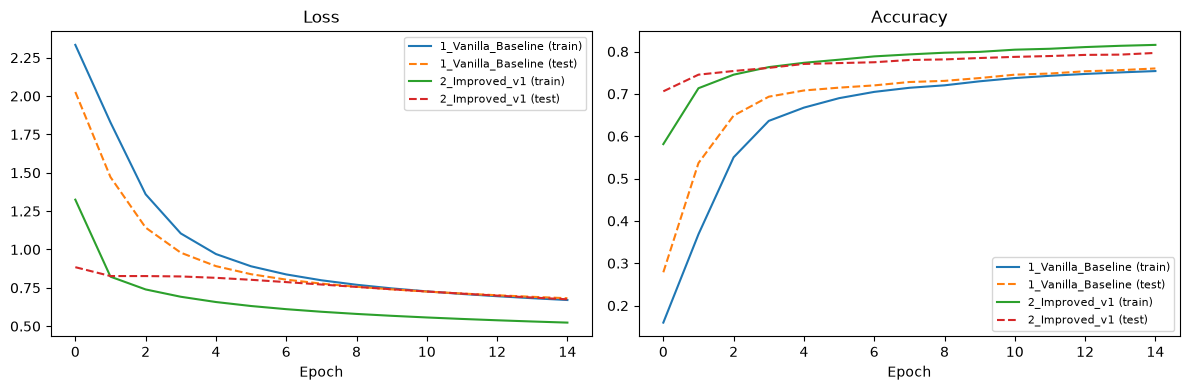

In [27]:
# 실험 1 학습 및 결과 확인
train_and_record(improved_model_v1, "2_Improved_v1", epochs=15)
plot_history(["1_Vanilla_Baseline", "2_Improved_v1"])


**실험 1 결과를 베이스라인과 비교해서 팀원과 이야기해보세요**
- 가설(왜 좋아질 것이라 예상했는지)과 실제 결과가 일치했나요?
- Train/Test 격차(Overfitting 정도)는 베이스라인보다 좋아졌나요, 나빠졌나요?

---

아래는 **실험 2**를 위한 셀입니다. 실험 1과는 **다른 포인트**를 바꿔서 비교해보세요.
(예: 실험 1에서 activation을 바꿨다면, 실험 2에서는 BatchNorm이나 Optimizer를 바꿔보는 식)


In [ ]:
# ✏️ [실험 2] 실험 1과는 다른 포인트를 바꿔서 비교해보세요 -> Conv2D 레이어를 2개로 늘림 (활성화 함수는 베이스라인과 동일하게 sigmoid 유지)
def build_improved_model_v2():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # ---- ✏️ TODO: 실험 1과 다른 변경 포인트를 시도해보세요 ----
        layers.Conv2D(8, (3, 3), activation="sigmoid"), 
        layers.Conv2D(8, (3, 3), activation="sigmoid"), #Conv2D 레이어를 2개로 늘림 (활성화 함수는 베이스라인과 동일하게 sigmoid 유지)
        layers.Flatten(),
                                   # 예시: Dropout 비율 변경
        # -------------------------------------------------------

        layers.Dense(10, activation="softmax"),
    ], name="improved_v2")

    model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )
    return model
improved_model_v2 = build_improved_model_v2()
improved_model_v2.summary()


Model: "improved_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │        46,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,754 (182.63 KB)

 Trainable params: 46,754 (182.63 KB)

 Non-trainable params: 0 (0.00 B)


=== [3_Improved_v2] 학습 시작 ===
[3_Improved_v2] 최종 Train Acc: 0.734 | Test Acc: 0.734 | 격차(Overfitting 정도): -0.001


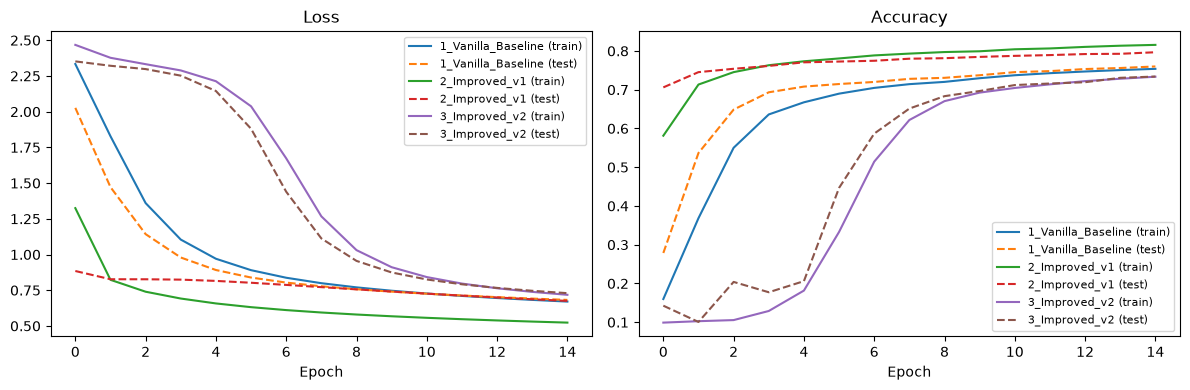

In [29]:
# 실험 2 학습 및 결과 확인
train_and_record(improved_model_v2, "3_Improved_v2", epochs=15)
plot_history()  # 지금까지의 모든 실험을 한 번에 비교


In [ ]:
# ✏️ [실험 2] 실험 1과는 다른 포인트를 바꿔서 비교해보세요 -> Conv2D 레이어를 2개로 늘림 + 활성화 함수 ReLU로 변경
def build_improved_model_v3():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # ---- ✏️ TODO: 실험 1과 다른 변경 포인트를 시도해보세요 ----
        layers.Conv2D(8, (3, 3), activation="relu"), #Conv2D 레이어를 2개로 늘림 + 활성화 함수 ReLU로 변경
        layers.Conv2D(8, (3, 3), activation="relu"),
        layers.Flatten(),
        # -------------------------------------------------------

        layers.Dense(10, activation="softmax"),
    ], name="improved_v3")

    model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )
    return model
improved_model_v3 = build_improved_model_v3()
improved_model_v3.summary()


Model: "improved_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 24, 24, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │        46,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,754 (182.63 KB)

 Trainable params: 46,754 (182.63 KB)

 Non-trainable params: 0 (0.00 B)


=== [3_Improved_v3] 학습 시작 ===
[3_Improved_v3] 최종 Train Acc: 0.822 | Test Acc: 0.803 | 격차(Overfitting 정도): 0.019


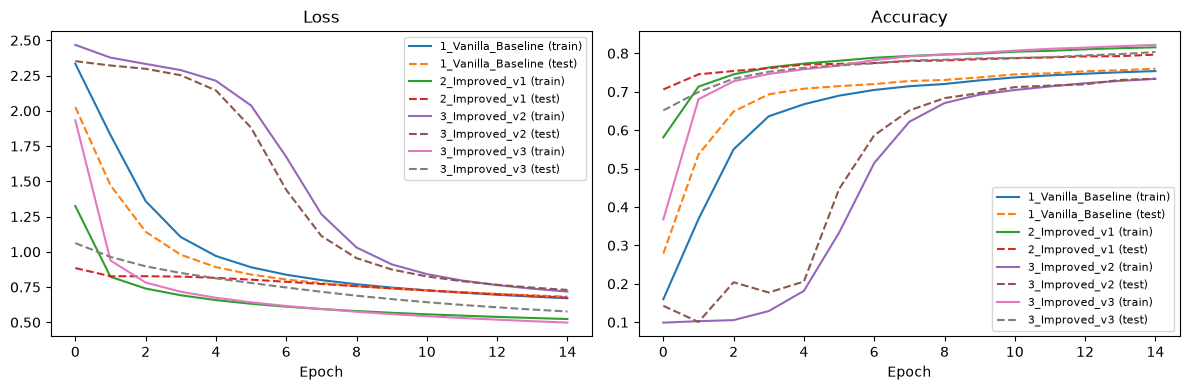

In [31]:
# 실험 2 학습 및 결과 확인
train_and_record(improved_model_v3, "3_Improved_v3", epochs=15)
plot_history()  # 지금까지의 모든 실험을 한 번에 비교


### (여유가 되면) 추가 실험
시간이 남는다면 `build_improved_model_v1`, `v2` 셀을 복사해서 `v3`를 만들어 더 실험해도 좋습니다.
단, **새로운 실험도 반드시 가설 → 결과 → 해석**의 흐름을 지켜주세요.


---
## 5. 결과 비교 & 정리 (15분)


In [32]:
# 지금까지의 모든 실험 결과를 표로 요약
summary_table()


실험명                    Train Acc    Test Acc        격차
1_Vanilla_Baseline         0.754       0.760    -0.006
2_Improved_v1              0.816       0.797     0.019
3_Improved_v2              0.734       0.734    -0.001
3_Improved_v3              0.822       0.803     0.019


**정리 질문 (보고서에 활용하세요)**
1. 가장 성능(Test Accuracy)이 좋았던 실험은 무엇인가요?
2. 가장 **Train/Test 격차가 작았던(=안정적인)** 실험은 무엇인가요? (성능이 가장 좋은 실험과 같지 않을 수도 있습니다.)
3. 여러분이 세웠던 가설 중 **예상과 다르게 나온 결과**가 있었나요? 왜 그랬을 것 같나요?
4. 만약 시간이 더 있다면, 다음에는 무엇을 시도해보고 싶나요?

> 이 질문들에 대한 답은 **"이게 제일 좋았어요"로 끝나면 안 됩니다.** 왜 그런 결과가 나왔는지에 대한 여러분의 해석이 포인트입니다.


---
## 6. 제출 안내 (10분)

### 제출물 (2가지)
1. **이 노트북 파일** (`.ipynb`) — 실행 결과(그래프 포함)가 모두 남아있는 상태로 저장 후 제출
   - `파일 > 다운로드 > .ipynb 다운로드` (Colab 기준)
2. **간단 보고서** (`.pdf`, 별도 제공된 템플릿 사용)
   - 베이스라인 구조/성능, 실험별 가설·결과·해석, 최종 결론을 포함

### 평가 기준 (참고)
| 항목 | 평가 내용 | 배점 |
|---|---|---|
| 아키텍처 개선 논리 | 개선 목표의 명확성, 설계 판단의 논리성 | 20 |
| 아키텍처 개선 설계 타당성 | 목적에 맞는 Layer/Optimizer/Activation 선정 | 15 |
| 학습 안정성 및 일반화 | Train/Test 성능 안정성(그래프), Overfitting 완화 여부 | 15 |

**수고하셨습니다.**
